<a href="https://colab.research.google.com/github/ikabrain/UML501-Machine-Learning-Lab/blob/main/ML_assign7/ML_assign7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Assignment 7: SVM
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1)** Iris dataset
---

The **Iris dataset** is a classic example for demonstrating classification algorithms. It consists of 150 samples of iris flowers belonging to three species: Setosa, Versicolor, and Virginica, with four input features (sepal and petal length/width).

Use SVC from sklearn.svm on the Iris dataset and follow the steps below:

### **a)** Load the dataset and perform train–test split (80:20).

In [2]:
# Loading dataset
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

df = iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# 80-20 split using STRATIFIED split
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training records: {y_train.shape[0]}')
print(f' Testing records: {y_test.shape[0]}')

Training records: 120
 Testing records: 30


In [4]:
y_train.value_counts()

,count
target,
0,40
2,40
1,40


In [5]:
y_test.value_counts()

,count
target,
0,10
2,10
1,10


### **b)** Train three different SVM models using the following kernels:

Linear, Polynomial (degree=3), RBF

In [6]:
from sklearn.svm import SVC

svm_models = list(dict())

In [7]:
# Training linear SVM

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

svm_models.append({"kernel": "linear", "model": linear_svm})

In [8]:
# Training polynomial (d=3) SVM

poly_svm = SVC(kernel='poly', degree=3)
poly_svm.fit(X_train, y_train)

svm_models.append({"kernel": "cubic polynomial", "model": poly_svm})

In [9]:
# Training Radial (RBF) Kernel

rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)

svm_models.append({"kernel": "radial", "model": rbf_svm})

### **c)** Evaluate each model using:

- Accuracy
- Precision
- Recall
- F1-Score

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for model in svm_models:
    kernel = model["kernel"]
    svm = model["model"]

    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"For SVM with {kernel} kernel:-")
    print(f"\tAccuracy: {accuracy:.4f}")
    print(f"\tPrecision: {precision:.4f}")
    print(f"\tRecall: {recall:.4f}")
    print(f"\tF1-Score: {f1:.4f}")

For SVM with linear kernel:-
	Accuracy: 1.0000
	Precision: 1.0000
	Recall: 1.0000
	F1-Score: 1.0000
For SVM with cubic polynomial kernel:-
	Accuracy: 0.9667
	Precision: 0.9697
	Recall: 0.9667
	F1-Score: 0.9666
For SVM with radial kernel:-
	Accuracy: 0.9667
	Precision: 0.9697
	Recall: 0.9667
	F1-Score: 0.9666


### **d)** Display the confusion matrix for each kernel.

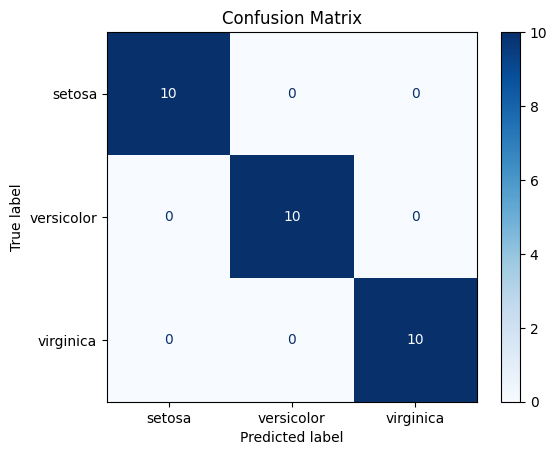

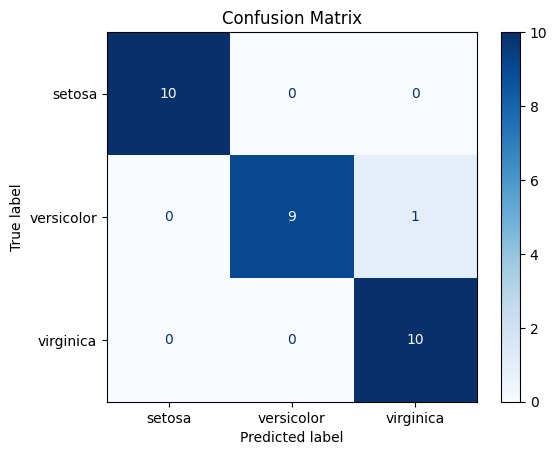

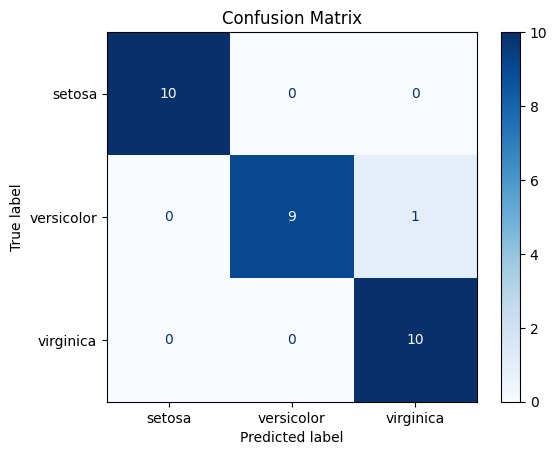

In [19]:
# Displaying the confusion matrix using sklearn's ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for model in svm_models:
    kernel = model["kernel"]
    svm = model["model"]

    y_pred = svm.predict(X_test)

    conf_matrix = confusion_matrix(y_test, y_pred)


    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=iris.target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')

plt.show()

### **e)** Identify which kernel performs the best and why.

Based on the evaluation metrics, the linear kernel performed the best, achieving 100% accuracy, precision, recall, and F1-score. This suggests that the Iris dataset is linearly separable (or nearly so) through a soft margin that defines a flat affine hyperplane as a decision boundary. The confusion matrices further illustrate this, as the linear kernel shows no misclassifications, while the polynomial and radial kernels each misclassified one sample.

## **2)** Feature Scaling
---

SVM models are highly sensitive to the scale of input features. When features have different ranges, the algorithm may incorrectly assign higher importance to variables with larger magnitudes, affecting the placement of the separating hyperplane. Feature scaling ensures that all attributes contribute equally to distance-based computations, which is especially crucial for kernels like RBF or polynomial.

### A) Use the **Breast Cancer dataset** from `sklearn.datasets.load_breast_cancer`.

### B) Train an SVM (RBF kernel) model **with** and **without** feature scaling (`StandardScaler`). Compare both results using:

- Training accuracy
- Testing accuracy

### C) Discuss the effect of feature scaling on SVM performance.